In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import bptf
from bptf import BPTF
import numpy as np
import pandas as pd
import sparse
import os
import shutil
from tqdm import tqdm
import pickle
import gdelt
import scipy.stats as st
import matplotlib.pyplot as plt
import torch
import tensorly
import cupy

from datetime import datetime, timedelta

import multiprocessing
from joblib import Parallel, delayed
from tqdm.contrib.concurrent import process_map

import requests
from bs4 import BeautifulSoup

import copy

print(os.getcwd())

import gc
gc.collect()

<IPython.core.display.Javascript object>

Kernel is restarting...
c:\Users\luiyu\Documents\aaron_schein\bptf_new


20

In [2]:
def make_date_list(start_date: str, end_date: str):
    """
    Generate a list of dates as "YYYY MM DD" between start_date and end_date (inclusive).
    Args:
        start_date: "YYYY-MM-DD"
        end_date:   "YYYY-MM-DD"
    Returns:
        List of strings ["YYYY MM DD", ...]
    """
    start = datetime.strptime(start_date, "%Y-%m-%d")
    end   = datetime.strptime(end_date,   "%Y-%m-%d")
    delta = timedelta(days=1)

    dates = []
    current = start
    while current <= end:
        dates.append(current.strftime("%Y %m %d"))
        current += delta

    return dates

def process_date(year, verbose = False):
    """
    Queries the GDELT database and returns all events with a complete token (i.e. source, target country, action and time) by day.
    GDELT 2 only supports 2015 02 18 and onwards.
    Args:
        year: string. YYYY
        verbose: boolean. True if you need a progress bar
    Returns:
        pandas dataframe with source, target country codes, action and day
    """
    try:
        ver = 1 if int(year) <= 2016 else 2
        gd = gdelt.gdelt(version=ver)
        range_ = [year + '-01-01', year + '-12-31']
        range_ = make_date_list(range_[0], range_[1])
        # print(range_[0], type(range_[0]))
        # results = gd.Search([date], table='events', coverage=True)
        # progress_bar = tqdm(range_, desc=f'Downloading GDELT {year}') if verbose else range_
        # results = [gd.Search(date=date, table='events', coverage=True) for date in progress_bar]
        # results = pd.concat(results)
        results = gd.Search(range_, table='events', coverage=True)
        results = results[['Actor1CountryCode', 'Actor2CountryCode', 'EventBaseCode', 'SQLDATE', 'NumMentions']]
        results.loc[:, 'EventBaseCode'] = results['EventBaseCode'].str[:2]
        results = results.dropna()
        # results = results.groupby(['Actor1CountryCode', 'Actor2CountryCode', 'EventBaseCode', 'SQLDATE'])
        # results = results.sum().reset_index()
        results = results[results['EventBaseCode'].str.isnumeric()]

        # print(f"Processed: {date} - {len(results)} rows")
        return results
    except Exception as e:
        print(f'Failed to process {year}: {e}')
        return pd.DataFrame(columns=['Actor1CountryCode', 'Actor2CountryCode', 'EventBaseCode', 'SQLDATE', 'NumMentions'])
    
# gdelt.gdelt(version=1).Search(make_date_list('2000-01-01', '2000-12-31')[0], table='events', coverage=True)
# process_date('2000', True)

In [ ]:
filepath = 'gdelt1.csv'
if os.path.exists(filepath):
    gdelt1 = pd.read_csv(filepath)
    print(f'{filepath} exists')
else:
    "At present the GDELT 2.0 data streams only stretch back to late morning February 19, 2015"
    "From the gdelt documentation"
    print('Downloading GDELT1')
    list_of_missing_years = list(range(2000, 2016))
    gdelt1 = []
    while len(list_of_missing_years) > 0:
        years_that_failed_to_download = []
        download_list = tqdm(list_of_missing_years.copy())
        for year in download_list:
            year_df = process_date(str(year))
            if len(year_df) > 0:
                gdelt1.append(year_df)
                download_list.set_description(f'{year} successfully downloaded')
            else:
                years_that_failed_to_download.append(year)
                download_list.set_description(f'{year} failed to download')
        list_of_missing_years = years_that_failed_to_download.copy()
        print(f'Missing years: {list_of_missing_years}')
        gc.collect()
    # gdelt1 = [process_date(str(year)) for year in tqdm(range(2000, 2016))]
    gdelt1 = pd.concat(gdelt1)
    gdelt1 = gdelt1[gdelt1['SQLDATE'] <= 20150218]
    gdelt1.to_csv(filepath, index=False)

print(f'Earliest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").min()}')
print(f'Latest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").max()}')

2005 successfully downloaded:  38%|███▊      | 6/16 [12:08<19:01, 114.15s/it]

Failed to process 2006: None: None


2007 failed to download:  50%|█████     | 8/16 [16:13<16:04, 120.60s/it]     

Failed to process 2007: None: None


2008 failed to download:  56%|█████▋    | 9/16 [17:12<11:49, 101.37s/it]

Failed to process 2008: None: None


In [ ]:
gdelt_filepaths = [os.path.join('GDELT', f) for f in os.listdir('GDELT')]

gdelt1_old = [pd.read_csv(gdelt_filepath) for gdelt_filepath in gdelt_filepaths]

gdelt1_old = pd.concat(gdelt1_old)

# combine the data
# we stack the data since the downloaded GDELT data is from before 2015 and the bigquery one is post-2015
# data = data[data['Database'] != 'GDELT']
gdelt1_old['Database'] = 'GDELT'
print(f'Earliest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").min()}')
print(f'Latest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").max()}')

gdelt1_old = gdelt1_old[gdelt1_old['SQLDATE'] <= 20150218]
print(f'Earliest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").min()}')
print(f'Latest date is {pd.to_datetime(gdelt1["SQLDATE"].astype(str), format="%Y%m%d").max()}')

Earliest date is NaT
Latest date is NaT
Earliest date is NaT
Latest date is NaT


Invalid SQLDATE entries:
 Series([], Name: SQLDATE, dtype: object)
Number of unparsed dates: 0


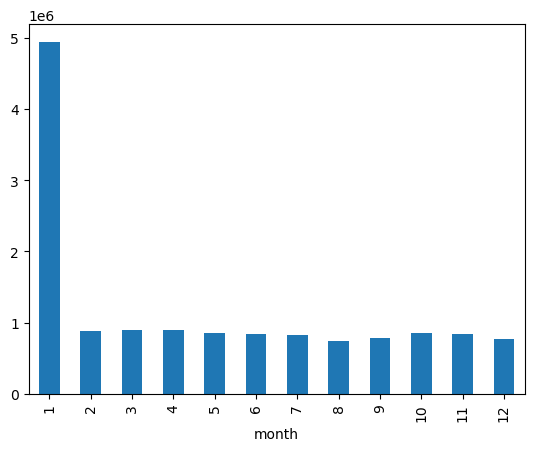

In [ ]:
lengths = gdelt1_old['SQLDATE'].astype(str).apply(len).unique()
# Convert to string (if not already done)
gdelt1_old['SQLDATE'] = gdelt1_old['SQLDATE'].astype(str)

# Create a boolean mask for rows that match the 8-digit pattern
mask = gdelt1_old['SQLDATE'].str.match(r'^\d{8}$')
invalid_dates = gdelt1_old.loc[~mask, 'SQLDATE']
print("Invalid SQLDATE entries:\n", invalid_dates)

gdelt1_old['SQLDATE'] = pd.to_datetime(gdelt1_old['SQLDATE'], format='%Y%m%d', errors='coerce')

# Check how many values could not be parsed
invalid_count = gdelt1_old['SQLDATE'].isna().sum()
print(f"Number of unparsed dates: {invalid_count}")

gdelt1_old['month'] = gdelt1_old['SQLDATE'].dt.month
month_counts = gdelt1_old['month'].value_counts().sort_index()

month_counts.plot(kind='bar')
plt.show()

0


IndexError: index 0 is out of bounds for axis 0 with size 0

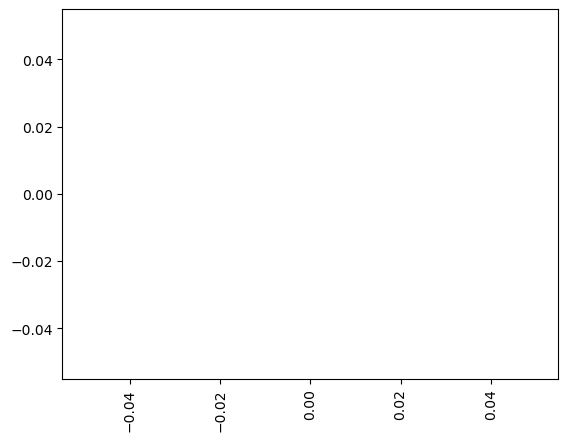

In [ ]:
gdelt1['SQLDATE'] = pd.to_datetime(gdelt1['SQLDATE'].astype(str), format='%Y%m%d')
gdelt1 = gdelt1.dropna()
gdelt1['month'] = gdelt1['SQLDATE'].dt.month
gdelt1['year'] = gdelt1['SQLDATE'].dt.year
month_counts = gdelt1['month'].value_counts().sort_index()
print(len(gdelt1))
month_counts.plot(kind='bar')
print(gdelt1.head())

year_month
2000-01    583710
2000-02    541982
2000-03    549320
2000-04    649782
2000-05    701006
Freq: M, Name: NumMentions, dtype: int64


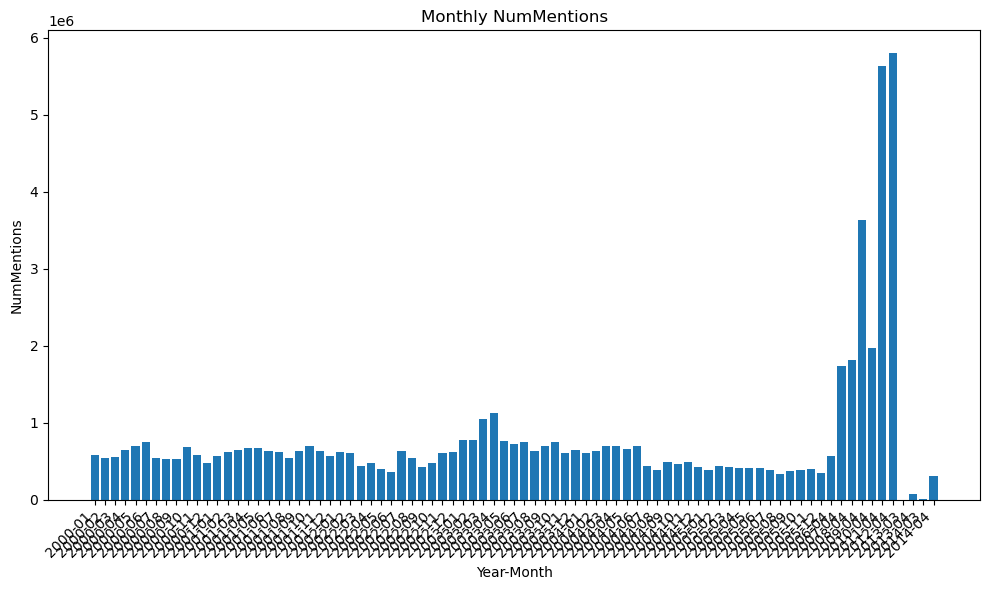

In [ ]:
monthly_total_counts = gdelt1.copy()
monthly_total_counts['year_month'] = monthly_total_counts['SQLDATE'].dt.to_period('M')
monthly_total_counts = monthly_total_counts.groupby('year_month')['NumMentions'].sum()
print(monthly_total_counts.head())

# plot
plt.figure(figsize=(10, 6))
plt.bar(monthly_total_counts.index.astype(str), monthly_total_counts.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Year-Month')
plt.ylabel('NumMentions')
plt.title('Monthly NumMentions')
plt.tight_layout()
plt.show()

In [ ]:
folder = "/icews_gdelt_terrier/"
data_filepath = os.getcwd() + folder
files = os.listdir(data_filepath)
data = [pd.read_csv(data_filepath + filepath) for filepath in files]
data = pd.concat(data)
# data = data.sort_values(by='Num_Events', ascending=False)
years = [str(2000 + x) for x in range(0, 25)]
data = data[data['formatteddate'].str.startswith(tuple(years))]

   Source_Country_Code Target_Country_Code  CAMEO_Code formatteddate  \
10                 CUB                 NaN           1    2000-06-09   
11                 AZE                 NaN           1    2003-05-05   
12                 ESP                 NaN           1    2004-04-26   
13                 THA                 NaN           1    2005-03-29   
14                 RUS                 NaN           1    2015-11-03   

    Num_Events Database  
10           1  TERRIER  
11           1  TERRIER  
12           1  TERRIER  
13           1  TERRIER  
14           1  TERRIER  


<Axes: xlabel='month'>

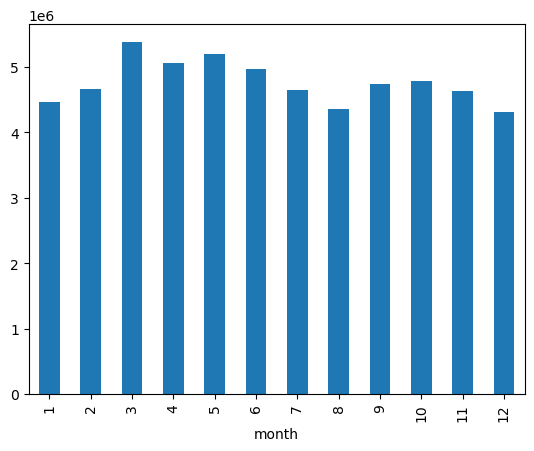

In [ ]:
print(data.head())
data['formatteddate'] = pd.to_datetime(data['formatteddate'], format='%Y-%m-%d')
data = data.dropna()
data['month'] = data['formatteddate'].dt.month
month_counts = data['month'].value_counts().sort_index()
month_counts.plot(kind='bar')

In [ ]:
gdelt1 = gdelt1.rename(
    columns={
        'Actor1CountryCode' : 'Source_Country_Code',
        'Actor2CountryCode' : 'Target_Country_Code',
        'EventBaseCode' : 'CAMEO_Code',
        'SQLDATE' : 'formatteddate',
        'NumMentions' : 'Num_Events'
    }
)
gdelt1['formatteddate'] = gdelt1['formatteddate'].dt.strftime('%Y-%m-%d')
gdelt1['Database'] = 'GDELT'
gdelt1 = gdelt1.dropna()
new_order = ['Source_Country_Code', 'Target_Country_Code', 'CAMEO_Code',
             'formatteddate', 'Num_Events', 'Database', 'month']
gdelt1 = gdelt1[new_order]
print(gdelt1.dtypes)

Source_Country_Code    object
Target_Country_Code    object
CAMEO_Code             object
formatteddate          object
Num_Events              int64
Database               object
month                   int32
dtype: object


In [ ]:
print(gdelt1.head())
print(data.head())

    Source_Country_Code Target_Country_Code CAMEO_Code formatteddate  \
702                 AFG                 AFG         02    2000-01-01   
703                 AFG                 AFG         08    2000-01-01   
704                 AFG                 ARE         03    2000-01-01   
712                 AFG                 IND         04    2000-01-01   
713                 AFG                 IND         04    2000-01-01   

     Num_Events Database  month  
702           9    GDELT      1  
703           9    GDELT      1  
704           2    GDELT      1  
712           7    GDELT      1  
713           9    GDELT      1  
      Source_Country_Code Target_Country_Code  CAMEO_Code formatteddate  \
25358                 PAN                 ABW           1    2015-09-27   
25359                 BRB                 ABW           2    2019-10-27   
25360                 ESP                 ABW           2    2017-11-13   
25361                 USA                 ABW           2    20

In [ ]:
combined_data = pd.concat([data, gdelt1])

In [ ]:
# Ensure 'formatteddate' is in datetime format and extract the year
data['formatteddate'] = pd.to_datetime(data['formatteddate'])
data['year'] = data['formatteddate'].dt.year

# --------------------------------------------
# Step 1: Compute duplicate counts per date, by year and Database
# --------------------------------------------
# Group by year and Database, then count occurrences of each 'formatteddate'
date_counts = data.groupby(['year', 'Database'])['formatteddate'].value_counts()

# For each date that appears more than once, the duplicate count is count - 1
duplicates_per_date = date_counts - 1

# Keep only dates that have duplicates (i.e. count > 0)
duplicates_per_date = duplicates_per_date[duplicates_per_date > 0]

# Sum the duplicate counts for each (year, Database) combination
duplicates_count = duplicates_per_date.groupby(level=[0, 1]).sum()

# --------------------------------------------
# Step 2: Compute total number of rows per (year, Database)
# --------------------------------------------
total_counts = data.groupby(['year', 'Database']).size()

# --------------------------------------------
# Step 3: Combine the totals and duplicates into a summary DataFrame
# --------------------------------------------
result = pd.DataFrame({
    'total_rows': total_counts,
    'duplicate_count': duplicates_count
})

# In case some groups have no duplicates, fill missing duplicate counts with 0
result['duplicate_count'] = result['duplicate_count'].fillna(0)

# Calculate the duplicate ratio (duplicate_count/total_rows)
result['duplicate_ratio'] = result['duplicate_count'] / result['total_rows']

print(result)

               total_rows  duplicate_count  duplicate_ratio
year Database                                              
2000 ICEWS         436351           435985         0.999161
     TERRIER       142681           142315         0.997435
2001 ICEWS         526679           526314         0.999307
     TERRIER       119508           119143         0.996946
2002 ICEWS         545167           544802         0.999330
     TERRIER       114531           114166         0.996813
2003 ICEWS         570447           570082         0.999360
     TERRIER       158737           158372         0.997701
2004 ICEWS         630368           630002         0.999419
     TERRIER       157049           156683         0.997670
2005 GDELT           1069              801         0.749298
     ICEWS         674246           673881         0.999459
     TERRIER       155097           154732         0.997647
2006 GDELT           1326             1019         0.768477
     ICEWS         731970           7316